In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
data = {
    "Year": [
        2015, 2016, 2017, 2018, 2019,
        2020, 2021, 2022, 2023, 2024,
        2015, 2017, 2018, 2020, 2022,
        2016, 2019, 2021, 2023, 2024
    ],
    
    "Kms_Driven": [
        80000, 70000, 60000, 50000, 40000,
        30000, 20000, 15000, 10000, 5000,
        90000, 65000, 55000, 35000, 18000,
        75000, 45000, 25000, 12000, 4000
    ],
    
    "Engine_CC": [
        1200, 1300, 1400, 1500, 1600,
        1500, 1600, 1800, 2000, 2200,
        1000, 1400, 1600, 1800, 2000,
        1200, 1500, 1600, 2000, 2200
    ],
    
    "Price_Lakh": [
        4.2, 4.8, 5.5, 6.3, 7.2,
        8.5, 9.5, 11.0, 13.0, 15.5,
        3.8, 5.2, 6.0, 8.0, 11.5,
        4.5, 7.0, 9.0, 13.5, 16.0
    ]
}

df = pd.DataFrame(data)

df.head()

,Year,Kms_Driven,Engine_CC,Price_Lakh
0,2015,80000,1200,4.2
1,2016,70000,1300,4.8
2,2017,60000,1400,5.5
3,2018,50000,1500,6.3
4,2019,40000,1600,7.2


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Rows: 20
Columns: 4

Column names:
Index(['Year', 'Kms_Driven', 'Engine_CC', 'Price_Lakh'], dtype='str')

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Year        20 non-null     int64  
 1   Kms_Driven  20 non-null     int64  
 2   Engine_CC   20 non-null     int64  
 3   Price_Lakh  20 non-null     float64
dtypes: float64(1), int64(3)
memory usage: 772.0 bytes


In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Year          0
Kms_Driven    0
Engine_CC     0
Price_Lakh    0
dtype: int64


In [5]:
df.describe()

,Year,Kms_Driven,Engine_CC,Price_Lakh
count,20.000000,20.000000,20.000000,20.00000
mean,2019.500000,40200.000000,1620.000000,8.50000
std,2.946898,26816.334378,336.545922,3.78668
min,2015.000000,4000.000000,1000.000000,3.80000
25%,2017.000000,17250.000000,1400.000000,5.42500
50%,2019.500000,37500.000000,1600.000000,7.60000
75%,2022.000000,61250.000000,1850.000000,11.12500
max,2024.000000,90000.000000,2200.000000,16.00000


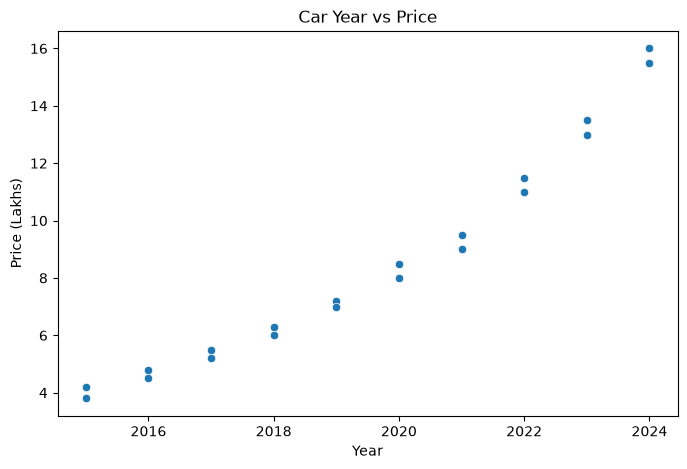

In [6]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Year",
    y="Price_Lakh"
)

plt.title("Car Year vs Price")
plt.xlabel("Year")
plt.ylabel("Price (Lakhs)")

plt.show()

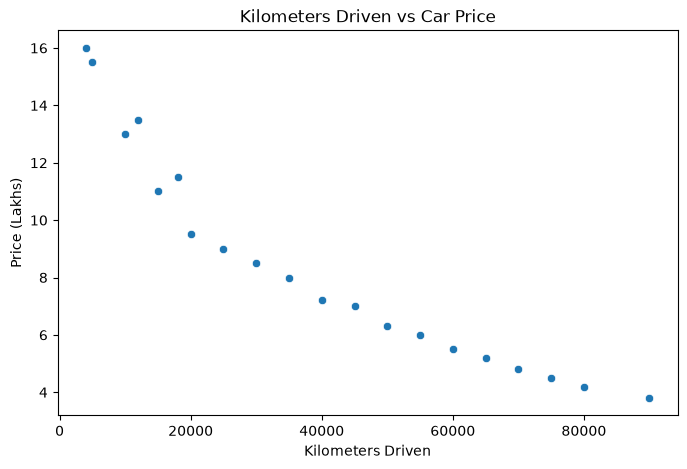

In [7]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Kms_Driven",
    y="Price_Lakh"
)

plt.title("Kilometers Driven vs Car Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Price (Lakhs)")

plt.show()

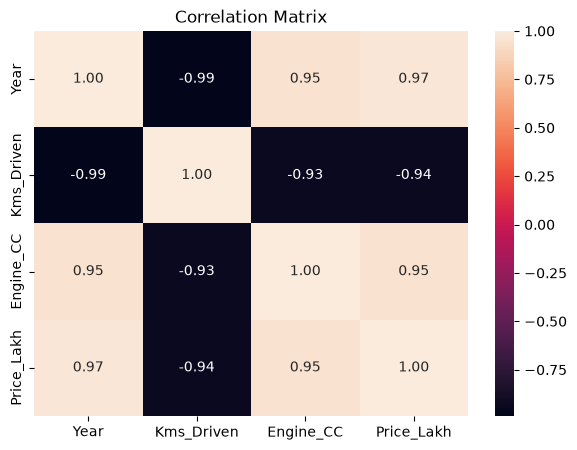

In [8]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [9]:
X = df[
    [
        "Year",
        "Kms_Driven",
        "Engine_CC"
    ]
]

y = df["Price_Lakh"]

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (20, 3)
Output shape: (20,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16, 3)
Testing data: (4, 3)


In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [12]:
y_pred = model.predict(X_test)

print("Actual prices:")
print(y_test.values)

print("\nPredicted prices:")
print(y_pred)

Actual prices:
[4.2 9.  4.5 4.8]

Predicted prices:
[ 2.156312   10.20803593  4.12395205  3.36683169]


In [13]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.2652350482867405


In [14]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 1.9578487326296012
Root Mean Squared Error: 1.3992314792876843


In [15]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.49039239105134835


In [16]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison

,Actual Price,Predicted Price
0,4.2,2.156312
1,9.0,10.208036
2,4.5,4.123952
3,4.8,3.366832


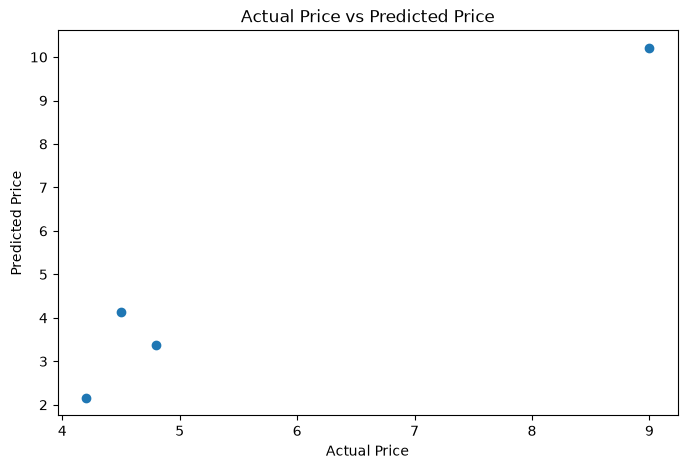

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")

plt.show()

In [18]:
new_car = pd.DataFrame({
    "Year": [2022],
    "Kms_Driven": [20000],
    "Engine_CC": [1600]
})

predicted_price = model.predict(new_car)

print("Predicted Car Price:", predicted_price[0], "Lakhs")

Predicted Car Price: 12.175675979671723 Lakhs


In [20]:
def predict_car_price(year, kms_driven, engine_cc):

    car = pd.DataFrame({
        "Year": [year],
        "Kms_Driven": [kms_driven],
        "Engine_CC": [engine_cc]
    })

    prediction = model.predict(car)

    return prediction[0]

In [21]:
price = predict_car_price(
    2021,
    25000,
    1500
)

print("Predicted Car Price:", round(price, 2), "Lakhs")

Predicted Car Price: 10.24 Lakhs


# Conclusion

In this project, a Car Price Prediction model was developed using
Machine Learning.

The dataset contains information about the car's manufacturing year,
kilometers driven, and engine capacity.

Data analysis and visualization were performed using Pandas,
Matplotlib, and Seaborn.

A Linear Regression model was trained using the car features to
predict the selling price.

The model was evaluated using Mean Absolute Error, Mean Squared
Error, Root Mean Squared Error, and R² Score.

The trained model can also predict the estimated price of a new car
based on its year, kilometers driven, and engine capacity.